In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = 12
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_for_test"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [98]:

library_size=1_000_000
add_size=1_000_000

ion_mode=[1,-1]
cache_list_threshold=[1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000]


In [99]:
df=[]
for threshold in cache_list_threshold:
    data={"cache_list_threshold":threshold,"number_of_spectra_per_file":1_000_000, "number_of_files":100}
    for charge in ion_mode:
        path_benchmark_specific_data_dynamic=path_benchmark_data/f"dynamic_fast_update_{charge}_compare_time_options_{threshold}_cache_list_threshold.txt"
        
        with open(path_benchmark_specific_data_dynamic,"r") as f:
            dynamic=float(f.readline().strip())
            
        data["dynamic_entropy_search(fast_update)"]=dynamic
        data["charge"]=charge
        df.append(pd.DataFrame([data]))
    
df=pd.concat(df)
df

,cache_list_threshold,number_of_spectra_per_file,number_of_files,dynamic_entropy_search(fast_update),charge
0,1000,1000000,100,13631.960456,1
0,1000,1000000,100,10458.767403,-1
0,5000,1000000,100,7539.682086,1
0,5000,1000000,100,5658.940879,-1
0,10000,1000000,100,6246.715962,1
0,10000,1000000,100,4550.635261,-1
0,50000,1000000,100,4934.515667,1
0,50000,1000000,100,3344.289968,-1
0,100000,1000000,100,4866.471048,1
0,100000,1000000,100,3203.629165,-1


In [100]:

df_data = df[["cache_list_threshold", 
              "charge",
            "dynamic_entropy_search(fast_update)", 
            ]]

df_melted=df_data.melt(id_vars=["charge", "cache_list_threshold"], var_name="type", value_name="time")
df_melted


,charge,cache_list_threshold,type,time
0,1,1000,dynamic_entropy_search(fast_update),13631.960456
1,-1,1000,dynamic_entropy_search(fast_update),10458.767403
2,1,5000,dynamic_entropy_search(fast_update),7539.682086
3,-1,5000,dynamic_entropy_search(fast_update),5658.940879
4,1,10000,dynamic_entropy_search(fast_update),6246.715962
5,-1,10000,dynamic_entropy_search(fast_update),4550.635261
6,1,50000,dynamic_entropy_search(fast_update),4934.515667
7,-1,50000,dynamic_entropy_search(fast_update),3344.289968
8,1,100000,dynamic_entropy_search(fast_update),4866.471048
9,-1,100000,dynamic_entropy_search(fast_update),3203.629165


In [ ]:
import matplotlib.ticker as ticker
def plot_time_options_cache_list_threshold(
    df,
    color_palette,
    ylim,
    save_path
):
    # df_charge=df_melted[df_melted["charge"]==charge]
    plt.figure(figsize=(6, 4))
    sns.barplot(x="cache_list_threshold", y="dynamic_entropy_search(fast_update)", hue="charge", data=df, 
                palette=color_palette, legend=True, width=0.6, errwidth=0)
    plt.ylabel("Index building time (seconds)")
    bottom=ylim[0]
    top=ylim[1]
    ax = plt.gca()
    current_labels = [int(label.get_text()) for label in ax.get_xticklabels()]
    new_labels = [f"{label:,}" for label in current_labels]
    ax.set_xticklabels(new_labels)
    plt.xticks(rotation=30)
    plt.ylim(top=top, bottom=bottom)
    plt.xlabel(f"Limit of cache list")
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ['(+)ESI' if label == '1' else '(-)ESI' for label in labels]
    ax.legend(handles, custom_labels,loc='upper center',bbox_to_anchor=(0.5,1.2), framealpha=0.9, ncol=2,frameon=False, )
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)
    

In [102]:
color_palette={
    1: '#ca3032',
    -1:"#32586d"
}

/tmp/ipykernel_2942601/755482892.py:10: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x="cache_list_threshold", y="dynamic_entropy_search(fast_update)", hue="charge", data=df,
/tmp/ipykernel_2942601/755482892.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


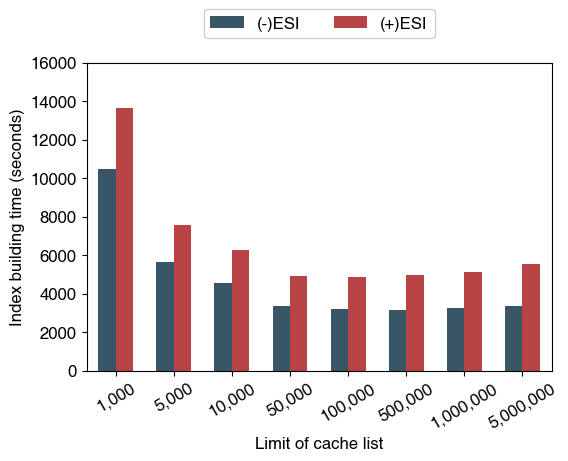

In [103]:
# charge=-1
ylim=(0,16000)
save_path=path_figures / f"compare_time_options_cache_list_threshold.svg"
plot_time_options_cache_list_threshold(
    df=df,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)